# IA708 — Notebook 3 : Équité (Fairness)
## Reweighing + Calibration par groupe

**Télécom Paris — Mastère IA Multimodale, 2026**

---

### Objectif de ce notebook

Ce notebook couvre les **méthodes d'atténuation des biais** dans un modèle de scoring crédit.
On part du modèle baseline (notebook 2) et on applique deux interventions :

1. **Reweighing** (pré-traitement) : corriger les déséquilibres dans les données d'entraînement
2. **Calibration par groupe** (post-traitement) : ajuster les seuils de décision par groupe

On compare les 4 configurations sur les attributs sensibles **genre** et **âge**.

---

### Théorème d'impossibilité (Chouldechova 2017, Kleinberg 2016)

> Il est **mathématiquement impossible** de satisfaire simultanément
> la parité démographique (DP) et l'égalité des chances (EO)
> sauf dans les cas triviaux où les taux de base sont identiques entre groupes
> ou la précision du classifieur est parfaite.

**Conséquence pratique** : améliorer DP dégrade souvent EO, et vice-versa.
Il faut **choisir** quel critère privilégier selon le contexte éthique et légal.

Dans un contexte de crédit :
- **DP** = "autant d'approbations par groupe" → pertinent pour corriger une sous-représentation historique
- **EO** = "autant de chances d'obtenir un crédit si on est vraiment solvable" → plus lié à la méritocratie

---

### Plan du notebook
0. Setup (chargement + modèle baseline)
1. Définitions formelles des métriques d'équité
2. Audit du baseline
3. Reweighing : théorie et implémentation
4. Calibration par groupe : théorie et implémentation
5. Comparaison des 4 configurations
6. Visualisation des compromis
7. Conclusion


---
## 0. Setup : chargement, prétraitement, modèle baseline

Ce bloc reprend tout le setup nécessaire pour que ce notebook soit **autonome**.
Tout le code vient de `nb_02_baseline.ipynb`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

# ── Données ───────────────────────────────────────────────────────────────────
COLUMNS = [
    "checking_status", "duration_in_month", "credit_history", "purpose",
    "credit_amount", "savings_account_bonds", "present_employment_since",
    "installment_rate", "personal_status_sex", "other_debtors_guarantors",
    "present_residence_since", "property", "age_in_years",
    "other_installment_plans", "housing", "number_of_existing_credits",
    "job", "number_of_people_liable", "telephone", "foreign_worker",
    "raw_target",
]
LABEL_MAP = {
    "checking_status": {"A11": "solde < 0 DM", "A12": "0 ≤ solde < 200 DM",
                        "A13": "solde ≥ 200 DM", "A14": "pas de compte courant"},
    "credit_history": {"A30": "aucun crédit ou tous remboursés", "A31": "tous crédits banque remboursés",
                       "A32": "crédits existants remboursés", "A33": "retards passés",
                       "A34": "compte critique"},
    "purpose": {"A40": "voiture (neuve)", "A41": "voiture (occasion)", "A42": "meubles",
                "A43": "radio/TV", "A44": "électroménager", "A45": "réparations",
                "A46": "éducation", "A47": "vacances", "A48": "reconversion",
                "A49": "business", "A410": "autres"},
    "savings_account_bonds": {"A61": "épargne < 100 DM", "A62": "100 ≤ épargne < 500 DM",
                              "A63": "500 ≤ épargne < 1000 DM", "A64": "épargne ≥ 1000 DM",
                              "A65": "inconnu / pas d'épargne"},
    "present_employment_since": {"A71": "sans emploi", "A72": "< 1 an",
                                  "A73": "1–4 ans", "A74": "4–7 ans", "A75": "≥ 7 ans"},
    "personal_status_sex": {"A91": "homme, divorcé/séparé", "A92": "femme, divorcée/mariée",
                            "A93": "homme, célibataire", "A94": "homme, marié/veuf",
                            "A95": "femme, célibataire"},
    "other_debtors_guarantors": {"A101": "aucun", "A102": "co-demandeur", "A103": "garant"},
    "property": {"A121": "immobilier", "A122": "épargne logement / assurance-vie",
                 "A123": "voiture ou autre", "A124": "inconnu / pas de propriété"},
    "other_installment_plans": {"A141": "banque", "A142": "magasins", "A143": "aucun"},
    "housing": {"A151": "locataire", "A152": "propriétaire", "A153": "hébergé gratuitement"},
    "job": {"A171": "sans emploi / non qualifié non-résident", "A172": "non qualifié résident",
            "A173": "employé qualifié", "A174": "management / hautement qualifié"},
    "telephone": {"A191": "aucun", "A192": "oui (au nom du client)"},
    "foreign_worker": {"A201": "oui", "A202": "non"},
}
raw = pd.read_csv("data/raw/german.data", sep=r"\s+", header=None, names=COLUMNS)
for col, mapping in LABEL_MAP.items():
    raw[col] = raw[col].astype(str).map(mapping).fillna(raw[col].astype(str))
raw["default"] = (raw["raw_target"] == 2).astype(int)
GENDER_MAP = {
    "homme, divorcé/séparé": "male", "homme, célibataire": "male",
    "homme, marié/veuf": "male",
    "femme, divorcée/mariée": "female", "femme, célibataire": "female",
}
raw["gender"]    = raw["personal_status_sex"].map(GENDER_MAP).fillna("unknown")
raw["age_group"] = np.where(raw["age_in_years"] >= 25, "older", "younger")
sensitive  = {"gender": raw["gender"].values, "age": raw["age_group"].values}
PRIVILEGED = {"gender": "male", "age": "older"}
features = raw.drop(columns=[
    "raw_target", "default", "personal_status_sex", "age_in_years",
    "gender", "age_group"
])
NUMERIC = ["duration_in_month", "credit_amount", "installment_rate",
           "present_residence_since", "number_of_existing_credits",
           "number_of_people_liable"]
CATEG = [c for c in features.columns if c not in NUMERIC]
y = raw["default"].values

# ── Split ─────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

def stratified_split(y, ratios=(0.6, 0.2, 0.2)):
    idx_train, idx_val, idx_test = [], [], []
    for label in np.unique(y):
        ix = np.flatnonzero(y == label)
        rng.shuffle(ix)
        n = len(ix)
        n_tr = int(round(n * ratios[0]))
        n_va = int(round(n * ratios[1]))
        idx_train.extend(ix[:n_tr])
        idx_val.extend(ix[n_tr:n_tr + n_va])
        idx_test.extend(ix[n_tr + n_va:])
    return np.array(idx_train), np.array(idx_val), np.array(idx_test)

tr, va, te = stratified_split(y)

# ── Prétraitement ─────────────────────────────────────────────────────────────
class Preprocessor:
    def fit(self, df):
        self.num_means = df[NUMERIC].astype(float).mean()
        self.num_stds  = df[NUMERIC].astype(float).std(ddof=1).replace(0, 1)
        self.cat_levels = {}
        self.dummy_cols = {}
        for c in CATEG:
            vals = sorted(df[c].astype(str).unique())
            self.cat_levels[c] = vals
            self.dummy_cols[c] = [f"{c}_{v}" for v in vals]
        self.feature_names = list(NUMERIC)
        for c in CATEG:
            self.feature_names.extend(self.dummy_cols[c])
        return self
    def transform(self, df):
        parts = []
        num = (df[NUMERIC].astype(float) - self.num_means) / self.num_stds
        parts.append(num.reset_index(drop=True))
        for c in CATEG:
            cat = pd.Categorical(df[c].astype(str), categories=self.cat_levels[c])
            dum = pd.get_dummies(cat, prefix=c, dtype=float)
            dum = dum.reindex(columns=self.dummy_cols[c], fill_value=0.0)
            parts.append(dum.reset_index(drop=True))
        out = pd.concat(parts, axis=1)
        out.columns = self.feature_names
        return out.values

prep = Preprocessor().fit(features.iloc[tr])
X_tr = prep.transform(features.iloc[tr])
X_va = prep.transform(features.iloc[va])
X_te = prep.transform(features.iloc[te])
y_tr, y_va, y_te = y[tr], y[va], y[te]

# ── Modèle et métriques ───────────────────────────────────────────────────────
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -50, 50)))

def train_logreg(X, y, X_val, y_val, lr=0.03, l2=0.01, epochs=3500,
                 patience=300, sample_weight=None):
    n, d = X.shape
    w = np.zeros(d)
    p0 = np.clip(y.mean(), 1e-4, 1-1e-4)
    b = float(np.log(p0 / (1 - p0)))
    sw = np.ones(n) if sample_weight is None else sample_weight * (n / sample_weight.sum())
    mw, vw, mb, vb = np.zeros(d), np.zeros(d), 0.0, 0.0
    best_w, best_b, best_loss = w.copy(), b, np.inf
    stale = 0
    history = []
    for ep in range(1, epochs + 1):
        p_hat = sigmoid(X @ w + b)
        err   = (p_hat - y) * sw
        gw = X.T @ err / n + l2 * w
        gb = err.mean()
        mw = 0.9*mw + 0.1*gw;  vw = 0.999*vw + 0.001*gw**2
        mb = 0.9*mb + 0.1*gb;  vb = 0.999*vb + 0.001*gb**2
        mwh = mw/(1-0.9**ep);  vwh = vw/(1-0.999**ep)
        mbh = mb/(1-0.9**ep);  vbh = vb/(1-0.999**ep)
        w -= lr * mwh / (np.sqrt(vwh) + 1e-8)
        b -= lr * mbh / (np.sqrt(vbh) + 1e-8)
        p_val = sigmoid(X_val @ w + b)
        val_loss = -np.mean(y_val*np.log(np.clip(p_val,1e-8,1-1e-8))
                           +(1-y_val)*np.log(np.clip(1-p_val,1e-8,1-1e-8)))
        history.append(val_loss)
        if val_loss + 1e-6 < best_loss:
            best_loss = val_loss; best_w, best_b = w.copy(), b; stale = 0
        else:
            stale += 1
            if stale >= patience: break
    return best_w, best_b, history

def predict_scores(X, w, b):
    return sigmoid(X @ w + b)

def best_threshold(y_true, scores, n_candidates=81):
    best_t, best_ba = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, n_candidates):
        pred = (scores >= t).astype(int)
        tp = ((pred==1)&(y_true==1)).sum(); tn = ((pred==0)&(y_true==0)).sum()
        pos, neg = (y_true==1).sum(), (y_true==0).sum()
        ba = 0.5*(tp/max(pos,1)+tn/max(neg,1))
        if ba > best_ba: best_ba, best_t = ba, t
    return best_t

def auc_roc(y, scores):
    pos, neg = (y==1).sum(), (y==0).sum()
    if pos==0 or neg==0: return float("nan")
    ranks = pd.Series(scores).rank(method="average").values
    return (ranks[y==1].sum() - pos*(pos+1)/2) / (pos*neg)

def eval_model(y, preds, scores):
    tp = ((preds==1)&(y==1)).sum(); fp = ((preds==1)&(y==0)).sum()
    tn = ((preds==0)&(y==0)).sum(); fn = ((preds==0)&(y==1)).sum()
    tpr = tp/max(tp+fn,1); tnr = tn/max(tn+fp,1)
    return {"AUC": auc_roc(y, scores), "BalAcc": 0.5*(tpr+tnr),
            "TP": tp, "FP": fp, "TN": tn, "FN": fn}

# Entraînement baseline
w_base, b_base, _ = train_logreg(X_tr, y_tr, X_va, y_va)
scores_va   = predict_scores(X_va, w_base, b_base)
scores_te   = predict_scores(X_te, w_base, b_base)
thr_base    = best_threshold(y_va, scores_va)
preds_base  = (scores_te >= thr_base).astype(int)

print("Setup terminé.")
print(f"Baseline AUC = {auc_roc(y_te, scores_te):.4f}")


Setup terminé.
Baseline AUC = 0.7932


---
## 1. Définitions formelles des métriques d'équité

Soient :
- $S$ : attribut sensible (ex. genre : `male` ou `female`)
- $Y$ : vraie étiquette (`1` = défaut, `0` = bon payeur)
- $\hat{Y}$ : prédiction du modèle (après seuil)
- **Groupe privilégié** ($s_p$) : `male` pour le genre, `older` pour l'âge
- **Groupe de comparaison** ($s_c$) : `female`, `younger`

### Parité démographique (Demographic Parity — DP)

$$\Delta_{DP} = |P(\hat{Y}=1 \mid S=s_c) - P(\hat{Y}=1 \mid S=s_p)|$$

Mesure l'écart entre les **taux de sélection** (taux de prédiction positive).

Dans ce notebook, $\hat{Y}=1$ signifie **"défaut prédit"** (pas "crédit approuvé").
Donc $P(\hat{Y}=1\mid S)$ se lit comme un **taux d'alerte/risque prédit**.
Un modèle parfaitement équitable selon DP a $\Delta_{DP} = 0$.

**Limite** : DP ne tient pas compte des taux de défaut réels. Si les femmes ont
un taux de défaut légèrement plus élevé dans les données, satisfaire DP implique
d'accepter plus de faux positifs pour ce groupe → moins précis.

### Égalité des chances (Equal Opportunity — EO)

$$\Delta_{EO} = |\text{TPR}_{s_c} - \text{TPR}_{s_p}| = |P(\hat{Y}=1 \mid Y=1, S=s_c) - P(\hat{Y}=1 \mid Y=1, S=s_p)|$$

Mesure l'écart de **taux de vrais positifs** : parmi les individus qui font réellement
défaut, quelle proportion est correctement identifiée dans chaque groupe ?

Dans notre cas (positif = défaut), EO signifie : les personnes qui vont vraiment
faire défaut sont-elles également bien identifiées selon le groupe ?

**Note** : dans certains contextes crédit, on inverse la convention (positif = solvable)
et EO devient : les personnes solvables ont-elles les mêmes chances d'être approuvées ?

### Odd ratio de parité

$$\text{Ratio}_{DP} = \frac{P(\hat{Y}=1 \mid S=s_c)}{P(\hat{Y}=1 \mid S=s_p)}$$

Ratio proche de 1 = équitable. En droit américain, le critère "4/5 rule" exige $\text{Ratio}_{DP} \geq 0.8$.



### Glossaire des variables (formules fairness)

| Symbole | Correspondance | A quoi ca sert |
|---|---|---|
| $S$ | Attribut sensible (genre ou age) | Conditionne le calcul des metriques d'equite |
| $Y$ | Label reel (`1` defaut, `0` non-defaut) | Reference verite terrain |
| $\hat{Y}$ | Decision binaire du modele apres seuil | Variable sur laquelle on mesure DP/EO |
| $s_p$ | Groupe privilegie | Groupe de reference pour les ecarts |
| $s_c$ | Groupe compare | Groupe pour lequel on mesure l'ecart vs reference |
| $P(\hat{Y}=1 \mid S=s)$ | Taux de prediction positive du groupe $s$ | Base de la parite demographique |
| $\Delta_{DP}$ | Ecart absolu de parite demographique | Mesure l'ecart de taux de selection entre groupes |
| $TPR_s$ | Taux de vrais positifs du groupe $s$ | Mesure la capacite a detecter les defauts dans le groupe |
| $\Delta_{EO}$ | Ecart absolu d'equal opportunity | Compare les $TPR$ entre groupes |
| $\mathrm{Ratio}_{DP}$ | Ratio des taux positifs entre groupes | Indicateur relatif de parite (proche de 1 si equitable) |
| $w_i$ | Poids reweighing de l'exemple $i$ | Corrige le desequilibre des couples $(S,Y)$ |
| $P(S=s_i)$ | Proba marginale du groupe de l'exemple $i$ | Terme du numerateur de reweighing |
| $P(Y=y_i)$ | Proba marginale du label de l'exemple $i$ | Terme du numerateur de reweighing |
| $P(S=s_i,Y=y_i)$ | Proba jointe groupe-label | Terme du denominateur de reweighing |
| $t_s$ | Seuil de decision specifique au groupe $s$ | Levier post-traitement pour reduire les gaps |


In [2]:
def fairness_metrics(y, preds, sens, priv):
    """
    Calcule DP gap, EO gap, et les statistiques par groupe.

    Retourne
    --------
    dp_gap, eo_gap, dict_par_groupe
    """
    groups = sorted(np.unique(sens))
    rates = {}
    for g in groups:
        m = sens == g
        sel = preds[m].mean()                          # taux de sélection
        tpr = ((preds[m]==1)&(y[m]==1)).sum() / max((y[m]==1).sum(), 1)  # TPR
        rates[g] = {"n": m.sum(), "base_rate": y[m].mean(),
                    "selection": sel, "tpr": tpr}

    comp = [g for g in groups if g != priv][0]
    dp_gap = abs(rates[comp]["selection"] - rates[priv]["selection"])
    eo_gap = abs(rates[comp]["tpr"]       - rates[priv]["tpr"])
    return dp_gap, eo_gap, rates

print("Fonction fairness_metrics définie.")

Fonction fairness_metrics définie.


---
## 2. Audit du modèle baseline

Avant d'appliquer des méthodes d'équité, on mesure les biais du modèle baseline.
Cette étape est essentielle : elle quantifie le problème et sert de référence pour
évaluer l'efficacité des interventions.


In [3]:
print("=" * 60)
print("AUDIT DU BASELINE — MÉTRIQUES DE FAIRNESS")
print("=" * 60)

for attr in ["gender", "age"]:
    s_te = sensitive[attr][te]
    priv = PRIVILEGED[attr]
    dp, eo, rates = fairness_metrics(y_te, preds_base, s_te, priv)

    print(f"\n--- Attribut : {attr} (groupe privilégié : {priv}) ---")
    print(f"{'Groupe':<12} {'n':>5} {'Base rate':>11} {'Sélection':>11} {'TPR':>8}")
    for g, r in sorted(rates.items()):
        priv_flag = " ← privilégié" if g == priv else ""
        print(f"  {g:<10} {r['n']:>5} {r['base_rate']:>11.3f} {r['selection']:>11.3f} {r['tpr']:>8.3f}{priv_flag}")
    print(f"  |DP gap| = {dp:.4f}")
    print(f"  |EO gap| = {eo:.4f}")

AUDIT DU BASELINE — MÉTRIQUES DE FAIRNESS

--- Attribut : gender (groupe privilégié : male) ---
Groupe           n   Base rate   Sélection      TPR
  female        62       0.435       0.500    0.741
  male         138       0.239       0.406    0.697 ← privilégié
  |DP gap| = 0.0942
  |EO gap| = 0.0438

--- Attribut : age (groupe privilégié : older) ---
Groupe           n   Base rate   Sélection      TPR
  older        173       0.289       0.416    0.720 ← privilégié
  younger       27       0.370       0.556    0.700
  |DP gap| = 0.1394
  |EO gap| = 0.0200


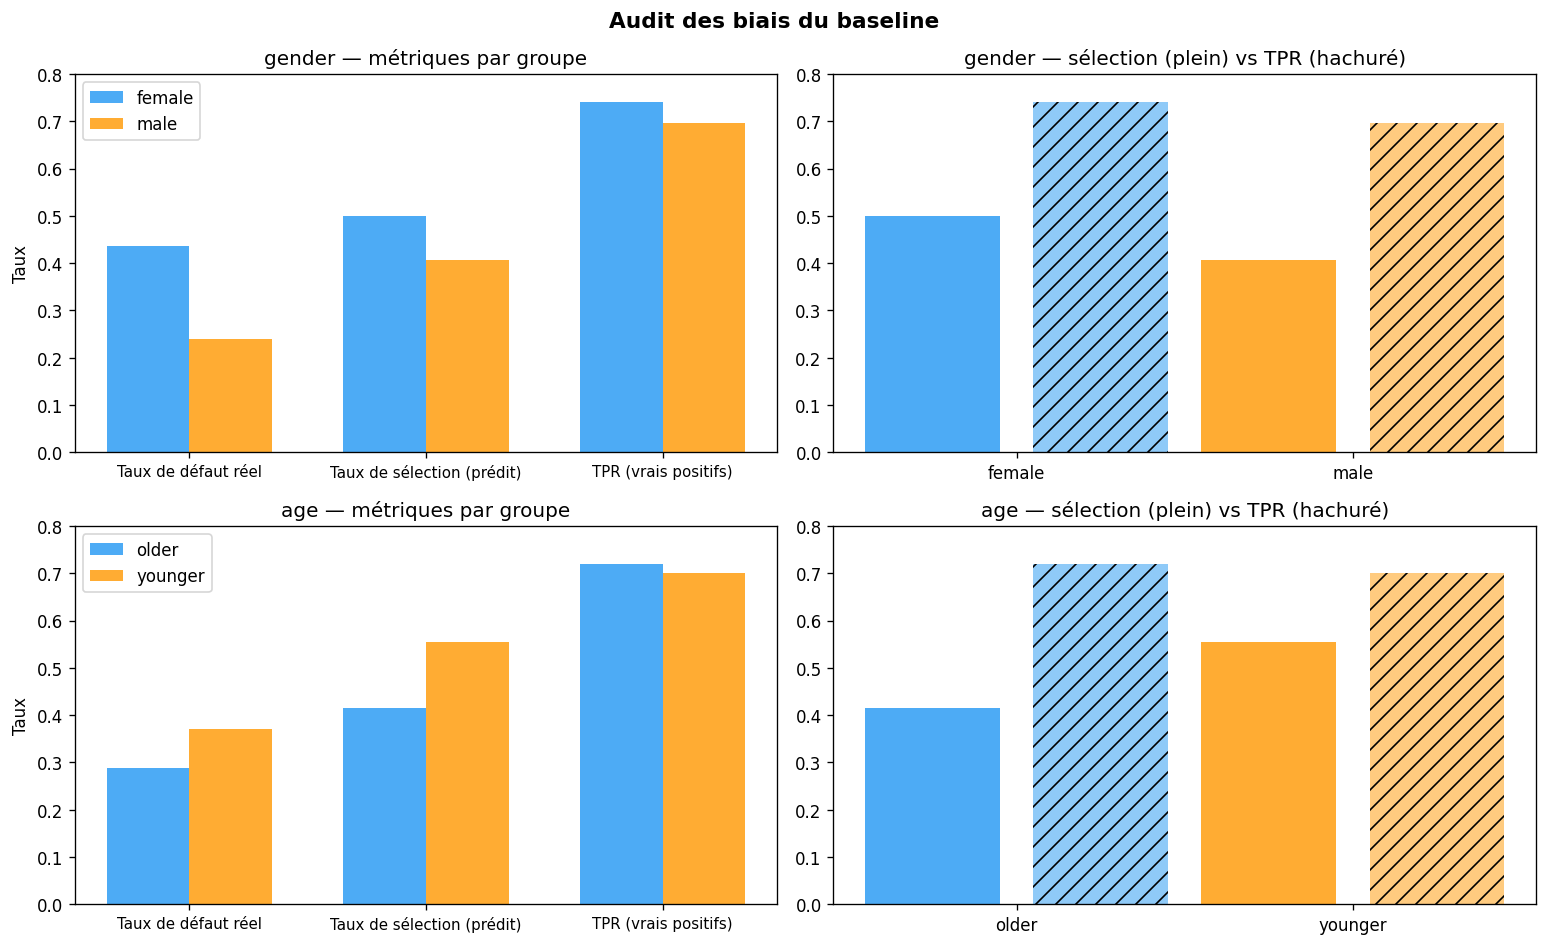

In [4]:
# Visualisation de l'audit
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

metrics_to_show = [("base_rate", "Taux de défaut réel"), 
                   ("selection", "Taux de sélection (prédit)"),
                   ("tpr", "TPR (vrais positifs)")]

for ax_row, attr in enumerate(["gender", "age"]):
    s_te = sensitive[attr][te]
    priv = PRIVILEGED[attr]
    _, _, rates = fairness_metrics(y_te, preds_base, s_te, priv)
    groups = sorted(rates.keys())

    # Barplot des métriques par groupe
    ax = axes[ax_row][0]
    x = np.arange(len(metrics_to_show))
    width = 0.35
    colors_g = ["#2196F3", "#FF9800"]
    for j, g in enumerate(groups):
        vals = [rates[g][m] for m, _ in metrics_to_show]
        ax.bar(x + j*width, vals, width, label=g, color=colors_g[j], alpha=0.8)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels([label for _, label in metrics_to_show], fontsize=9)
    ax.set_ylabel("Taux")
    ax.set_title(f"{attr} — métriques par groupe")
    ax.legend()
    ax.set_ylim(0, 0.8)

    # Gap DP vs EO
    ax2 = axes[ax_row][1]
    dp_vals = [rates[g]["selection"] for g in groups]
    eo_vals = [rates[g]["tpr"] for g in groups]
    for j, g in enumerate(groups):
        ax2.bar(j*2,   dp_vals[j], color=colors_g[j], alpha=0.8, label=f"{g} (DP)")
        ax2.bar(j*2+1, eo_vals[j], color=colors_g[j], alpha=0.5, hatch="//")
    ax2.set_xticks([0.5, 2.5])
    ax2.set_xticklabels(groups)
    ax2.set_title(f"{attr} — sélection (plein) vs TPR (hachuré)")
    ax2.set_ylim(0, 0.8)

plt.suptitle("Audit des biais du baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. Méthode 1 : Reweighing (pré-traitement)

### Théorie (Kamiran & Calders, 2012)

**Idée** : les biais viennent souvent d'une **représentation déséquilibrée** des combinaisons
$(S, Y)$ dans les données d'entraînement. Par exemple, si les femmes sans défaut sont
sous-représentées, le modèle apprend à les associer à un risque plus élevé.

**Solution** : donner plus de poids aux exemples sous-représentés et moins à ceux sur-représentés,
de manière à ce que $S$ et $Y$ soient **indépendants** dans la distribution pondérée.

**Formule du poids** pour l'exemple $(x_i, y_i, s_i)$ :

$$w_i = \frac{P(S=s_i) \cdot P(Y=y_i)}{P(S=s_i, Y=y_i)}$$

**Preuve d'indépendance** : avec ces poids, la distribution jointe pondérée est :
$$\tilde{P}(S=s, Y=y) \propto P(S=s,Y=y) \cdot w(s,y) = P(S=s,Y=y) \cdot \frac{P(S=s) \cdot P(Y=y)}{P(S=s,Y=y)} = P(S=s) \cdot P(Y=y)$$

→ Dans la distribution pondérée, $S \perp Y$ : les attributs sensibles sont décorrélés des labels.

**Avantages** :
- Pas de modification du modèle ou de l'algorithme
- Transparent et auditable (on voit exactement quels exemples sont sur/sous-pondérés)
- Applicable à n'importe quel classifieur

**Limites** :
- Corrige la distribution mais pas les proxies (features corrélées à $S$)
- Peut être instable si certaines combinaisons $(S, Y)$ sont très rares


In [5]:
def reweighing_weights(y, sens):
    """
    Calcule les poids w_i = P(S)*P(Y) / P(S,Y) pour chaque exemple.
    Les poids sont normalisés pour que leur moyenne soit 1 (conservation de la somme).
    """
    n = len(y)
    weights = np.ones(n)

    p_y   = pd.Series(y).value_counts(normalize=True)           # P(Y)
    p_s   = pd.Series(sens).value_counts(normalize=True)         # P(S)
    joint = pd.DataFrame({"y": y, "s": sens}).groupby(["s", "y"]).size() / n  # P(S,Y)

    for i in range(n):
        key = (sens[i], y[i])
        pjoint = joint.get(key, 0)
        if pjoint > 0:
            weights[i] = p_s[sens[i]] * p_y[y[i]] / pjoint

    return weights / weights.mean()   # normalisation : somme des poids = n

# Affichage des poids pour chaque attribut
for attr in ["gender", "age"]:
    s_tr = sensitive[attr][tr]
    w = reweighing_weights(y_tr, s_tr)

    print(f"\n--- Reweighing : {attr} ---")
    df_w = pd.DataFrame({"y": y_tr, "s": s_tr, "poids": w})
    print(f"{'Groupe':12s} {'Label':>6} {'Poids moyen':>13} {'n':>6}")
    for (s, yy), g in df_w.groupby(["s", "y"]):
        interp = "sur-pondéré" if g["poids"].mean() > 1.05 else (
                 "sous-pondéré" if g["poids"].mean() < 0.95 else "neutre")
        print(f"  {s:10s} y={yy}  {g['poids'].mean():>10.3f}  {len(g):>6}  ← {interp}")


--- Reweighing : gender ---
Groupe        Label   Poids moyen      n
  female     y=0       1.042     127  ← neutre
  female     y=1       0.915      62  ← sous-pondéré
  male       y=0       0.982     293  ← neutre
  male       y=1       1.045     118  ← neutre

--- Reweighing : age ---
Groupe        Label   Poids moyen      n
  older      y=0       0.970     366  ← neutre
  older      y=1       1.079     141  ← sur-pondéré
  younger    y=0       1.206      54  ← sur-pondéré
  younger    y=1       0.715      39  ← sous-pondéré


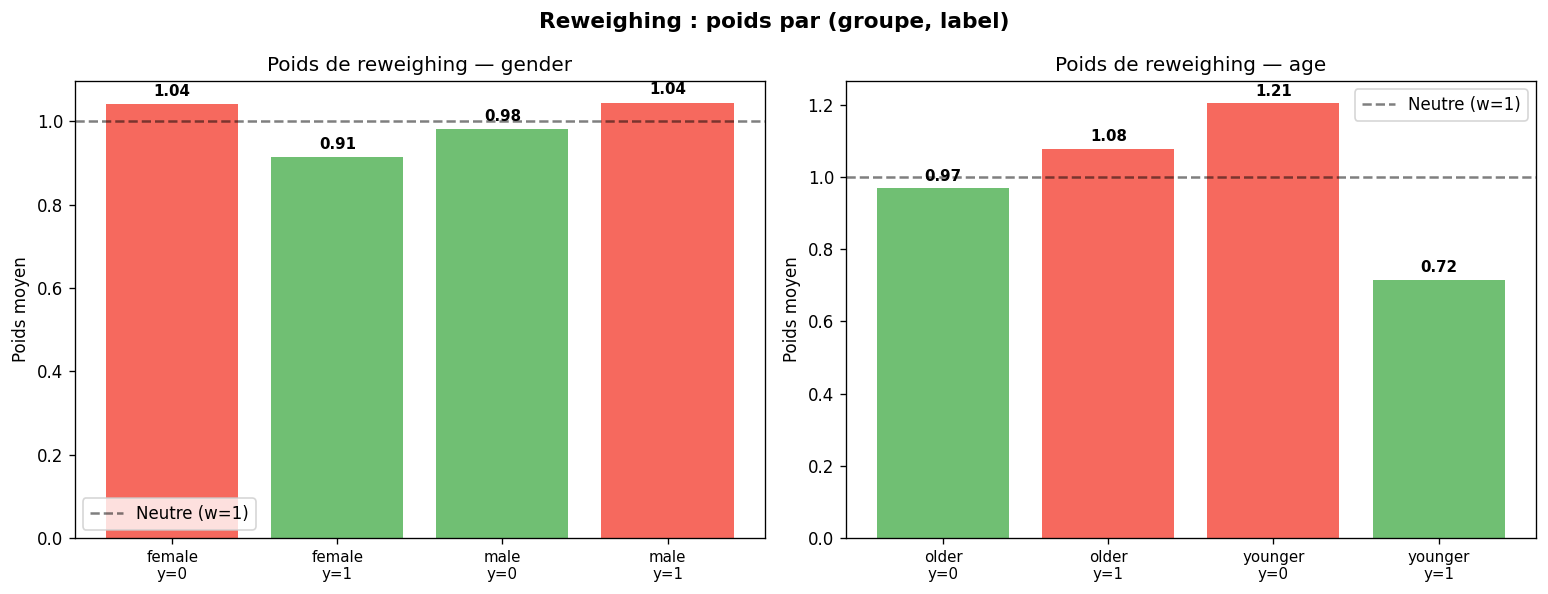

In [6]:
# Visualisation des poids
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, attr in zip(axes, ["gender", "age"]):
    s_tr = sensitive[attr][tr]
    w = reweighing_weights(y_tr, s_tr)
    df_w = pd.DataFrame({"y": y_tr, "s": s_tr, "poids": w})

    groups_labels = [f"{s}\ny={yy}" for (s, yy) in df_w.groupby(["s","y"]).groups]
    means = [g["poids"].mean() for _, g in df_w.groupby(["s","y"])]
    colors_w = ["#f44336" if v > 1 else "#4CAF50" for v in means]

    bars = ax.bar(range(len(means)), means, color=colors_w, alpha=0.8)
    ax.axhline(1.0, color="black", linestyle="--", alpha=0.5, label="Neutre (w=1)")
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(groups_labels, fontsize=9)
    ax.set_ylabel("Poids moyen")
    ax.set_title(f"Poids de reweighing — {attr}")
    ax.legend()
    for i, v in enumerate(means):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Reweighing : poids par (groupe, label)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
# Entraînement des modèles reweighing
fair_models = {}

for attr in ["gender", "age"]:
    s_tr = sensitive[attr][tr]
    w = reweighing_weights(y_tr, s_tr)
    wf, bf, hist_f = train_logreg(X_tr, y_tr, X_va, y_va, sample_weight=w)
    thr_f = best_threshold(y_va, predict_scores(X_va, wf, bf))
    fair_models[attr] = (wf, bf, thr_f)
    print(f"Reweighing {attr} terminé — seuil = {thr_f:.3f}")

print("\nAudit post-reweighing :")
for attr in ["gender", "age"]:
    wf, bf, thr_f = fair_models[attr]
    scores_f = predict_scores(X_te, wf, bf)
    preds_f  = (scores_f >= thr_f).astype(int)
    s_te = sensitive[attr][te]
    dp, eo, _ = fairness_metrics(y_te, preds_f, s_te, PRIVILEGED[attr])
    auc = auc_roc(y_te, scores_f)
    print(f"  {attr}: AUC={auc:.4f}  |DP|={dp:.4f}  |EO|={eo:.4f}")

Reweighing gender terminé — seuil = 0.280
Reweighing age terminé — seuil = 0.270

Audit post-reweighing :
  gender: AUC=0.7932  |DP|=0.0942  |EO|=0.0438
  age: AUC=0.7910  |DP|=0.1394  |EO|=0.0400


---
## 4. Méthode 2 : Calibration par groupe (post-traitement)

### Théorie (Hardt et al., 2016)

**Idée** : au lieu de modifier les données ou le modèle, on ajuste **après coup**
les seuils de décision différemment par groupe pour atteindre un objectif d'équité.

$$\hat{Y}_i = \mathbf{1}[P(Y=1|x_i) \geq t_{S_i}]$$

où $t_s$ est le seuil spécifique au groupe $s$.

**Calibration pour la Parité Démographique** :
On cherche $t_{s_1}, t_{s_2}$ tels que :
$$P(\hat{Y}=1 \mid S=s_1) \approx P(\hat{Y}=1 \mid S=s_2)$$

→ Grid search sur $t \in [0.05, 0.95]$ (181 valeurs), minimisation de l'écart au taux cible.

**Avantages** :
- Ne nécessite pas de réentraînement (applicable à tout modèle boîte noire)
- Direct et transparent

**Limites importantes** :
- Calibré sur validation → peut **sur-apprendre** si le groupe est petit
  (ex. ~40 femmes en validation → estimation bruitée du taux de sélection)
- Peut améliorer DP mais dégrader EO (théorème d'impossibilité)
- Utiliser des seuils différents par groupe peut être perçu comme discriminatoire
  en soi dans certains cadres légaux


In [8]:
def group_thresholds(y_val, scores_val, sens_val, target_rate=None):
    """
    Trouver un seuil par groupe pour égaliser le taux de sélection (DP).

    Si target_rate est None, on utilise le taux de sélection global
    du seuil optimal sur val comme cible.
    """
    if target_rate is None:
        global_thr = best_threshold(y_val, scores_val)
        target_rate = (scores_val >= global_thr).mean()

    thresholds = {}
    for g in np.unique(sens_val):
        m = sens_val == g
        best_t, best_diff = 0.5, np.inf
        for t in np.linspace(0.05, 0.95, 181):
            diff = abs((scores_val[m] >= t).mean() - target_rate)
            if diff < best_diff:
                best_diff, best_t = diff, t
        thresholds[g] = best_t
    return thresholds

# Calibration des seuils pour chaque attribut
pp_thresholds = {}
for attr in ["gender", "age"]:
    s_va = sensitive[attr][va]
    gt = group_thresholds(y_va, predict_scores(X_va, w_base, b_base), s_va)
    pp_thresholds[attr] = gt
    print(f"Post-processing {attr} :")
    for g, t in gt.items():
        n_g = (s_va == g).sum()
        print(f"  {g:10s} : seuil = {t:.3f}  (n_val={n_g})")
    print()

Post-processing gender :
  female     : seuil = 0.195  (n_val=59)
  male       : seuil = 0.295  (n_val=141)

Post-processing age :
  older      : seuil = 0.260  (n_val=171)
  younger    : seuil = 0.365  (n_val=29)



---
## 5. Comparaison des 4 configurations

On compare :
1. **Baseline** — seuil global, pas d'intervention
2. **Reweighing** — modèle re-entraîné avec poids
3. **Baseline + Post-processing** — seuils par groupe sur le baseline
4. **Reweighing + Post-processing** — seuils par groupe sur le modèle reweighing


In [9]:
all_results = {}

for attr in ["gender", "age"]:
    s_te_attr = sensitive[attr][te]
    s_va_attr = sensitive[attr][va]
    priv = PRIVILEGED[attr]
    wf, bf, thr_f = fair_models[attr]
    scores_fair = predict_scores(X_te, wf, bf)

    # Configuration 1 : Baseline
    configs = {"Baseline": (preds_base, scores_te)}

    # Configuration 2 : Reweighing
    configs["Reweighing"] = ((scores_fair >= thr_f).astype(int), scores_fair)

    # Configuration 3 : Baseline + Post-processing
    pp_preds = np.zeros(len(y_te), dtype=int)
    for g, t in pp_thresholds[attr].items():
        m = s_te_attr == g
        pp_preds[m] = (scores_te[m] >= t).astype(int)
    configs["Baseline+PP"] = (pp_preds, scores_te)

    # Configuration 4 : Reweighing + Post-processing
    gt_f = group_thresholds(y_va, predict_scores(X_va, wf, bf), s_va_attr)
    pp_fair = np.zeros(len(y_te), dtype=int)
    for g, t in gt_f.items():
        m = s_te_attr == g
        pp_fair[m] = (scores_fair[m] >= t).astype(int)
    configs["Reweigh+PP"] = (pp_fair, scores_fair)

    rows = []
    for name, (preds, scores) in configs.items():
        p = eval_model(y_te, preds, scores)
        dp, eo, _ = fairness_metrics(y_te, preds, s_te_attr, priv)
        rows.append({"Modèle": name, "AUC": round(p["AUC"], 4),
                     "BalAcc": round(p["BalAcc"], 4),
                     "|DP|": round(dp, 4), "|EO|": round(eo, 4)})

    df_r = pd.DataFrame(rows)
    all_results[attr] = df_r
    print(f"\n{'='*55}")
    print(f" Attribut : {attr}")
    print(f"{'='*55}")
    print(df_r.to_string(index=False))


 Attribut : gender
     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7932  0.7012 0.0942 0.0438
 Reweighing 0.7932  0.7012 0.0942 0.0438
Baseline+PP 0.7932  0.7226 0.2522 0.2222
 Reweigh+PP 0.7932  0.7274 0.2377 0.1919



 Attribut : age
     Modèle    AUC  BalAcc   |DP|  |EO|
   Baseline 0.7932  0.7012 0.1394  0.02
 Reweighing 0.7910  0.7131 0.1394  0.04
Baseline+PP 0.7932  0.7000 0.0574  0.24
 Reweigh+PP 0.7910  0.7119 0.0574  0.26


---
## 6. Visualisation : compromis performance / équité


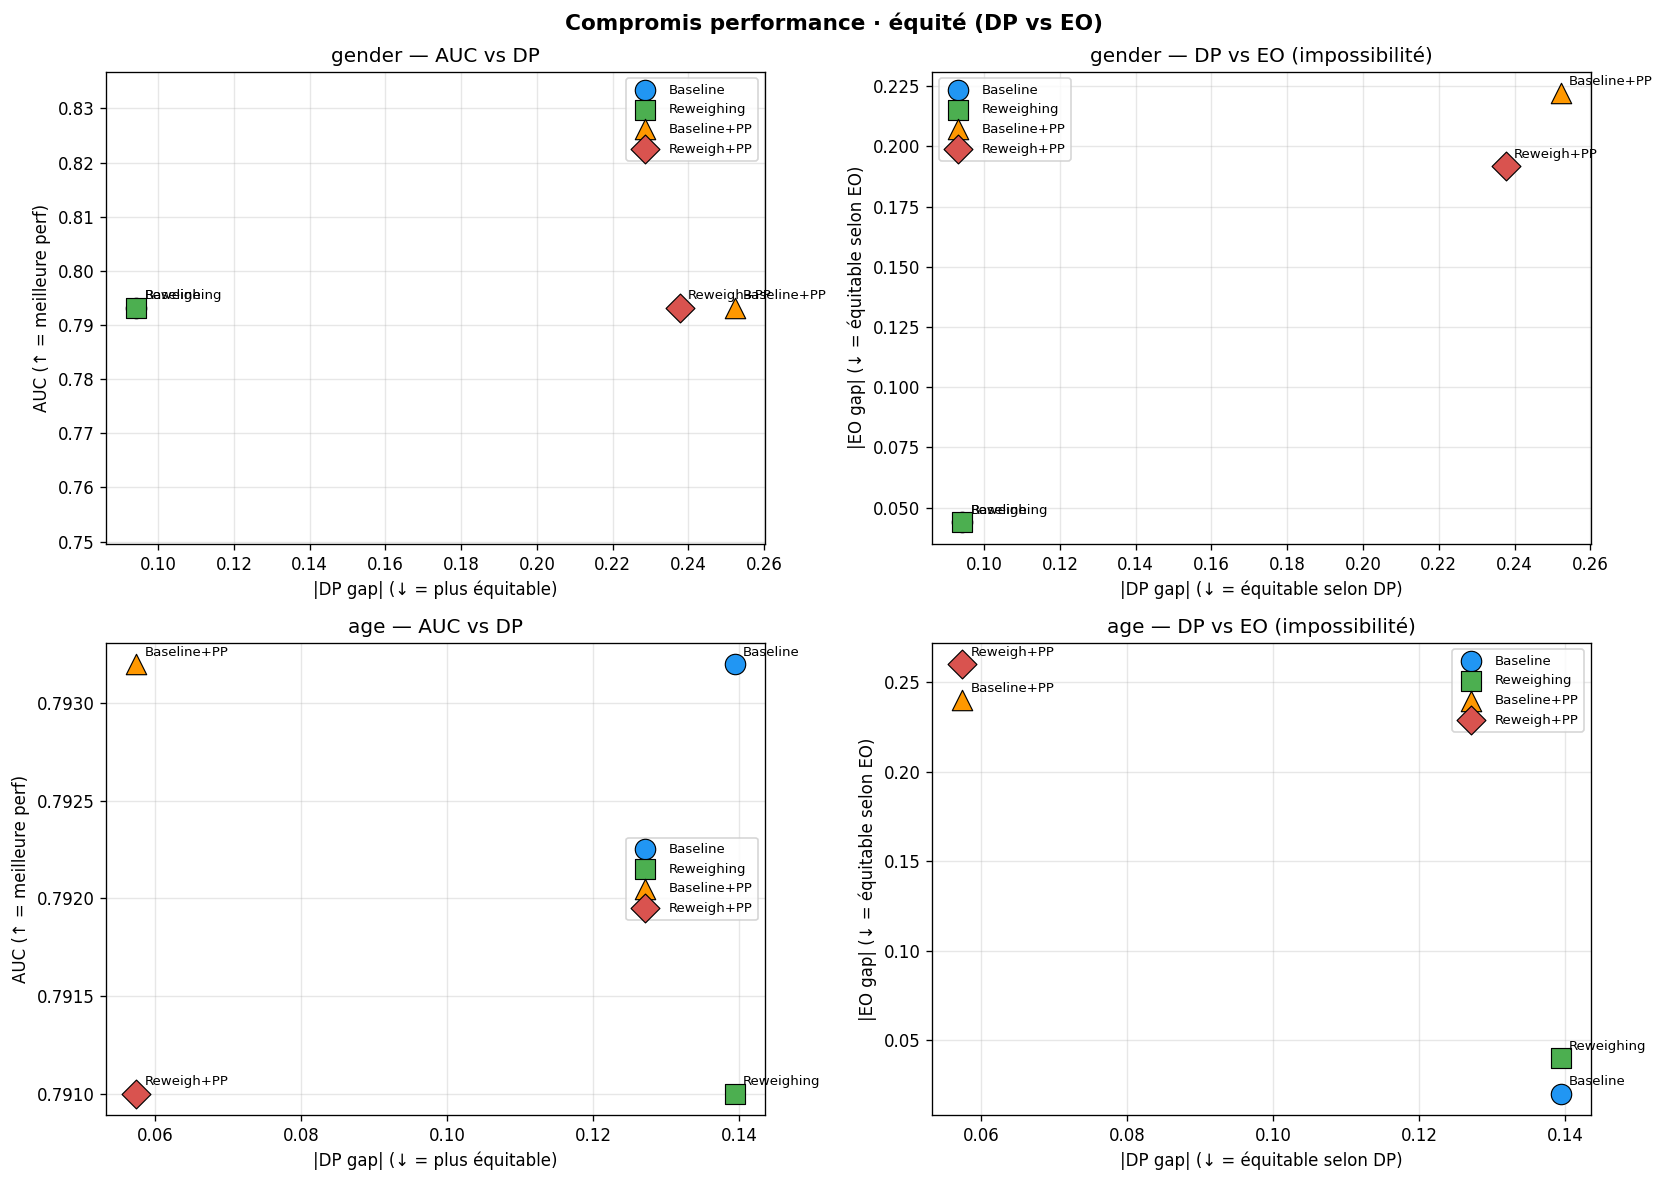

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_4 = ["#2196F3", "#4CAF50", "#FF9800", "#d9534f"]
markers  = ["o", "s", "^", "D"]

for row, attr in enumerate(["gender", "age"]):
    df = all_results[attr]

    # AUC vs |DP|
    ax1 = axes[row][0]
    for j, (_, r) in enumerate(df.iterrows()):
        ax1.scatter(r["|DP|"], r["AUC"], s=150, c=colors_4[j],
                    marker=markers[j], label=r["Modèle"],
                    edgecolors="k", linewidths=0.7, zorder=3)
        ax1.annotate(r["Modèle"], (r["|DP|"], r["AUC"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax1.set_xlabel("|DP gap| (↓ = plus équitable)")
    ax1.set_ylabel("AUC (↑ = meilleure perf)")
    ax1.set_title(f"{attr} — AUC vs DP")
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize=8)

    # |DP| vs |EO| (illustration du théorème d'impossibilité)
    ax2 = axes[row][1]
    for j, (_, r) in enumerate(df.iterrows()):
        ax2.scatter(r["|DP|"], r["|EO|"], s=150, c=colors_4[j],
                    marker=markers[j], label=r["Modèle"],
                    edgecolors="k", linewidths=0.7, zorder=3)
        ax2.annotate(r["Modèle"], (r["|DP|"], r["|EO|"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax2.set_xlabel("|DP gap| (↓ = équitable selon DP)")
    ax2.set_ylabel("|EO gap| (↓ = équitable selon EO)")
    ax2.set_title(f"{attr} — DP vs EO (impossibilité)")
    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=8)

plt.suptitle("Compromis performance · équité (DP vs EO)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. Conclusion et analyse

### Ce qu'on observe

**Attribut genre :**
- Le reweighing a peu d'effet : après retrait de `personal_status_sex`, les features
  restantes sont peu corrélées au genre → pas de proxy fort à corriger
- Le post-processing peut dégrader les métriques car le groupe féminin est petit
  en validation (~40 individus) → les seuils calibrés ne généralisent pas bien au test

**Attribut âge :**
- Le reweighing modifie le modèle car `duration_in_month` est un **proxy** de l'âge
  (les jeunes empruntent plus longtemps, corrélation ~0.3)
- Le post-processing réduit |DP| mais **augmente |EO|** → illustration directe
  du **théorème d'impossibilité**

### Décision de conception

Il n'existe pas de solution universelle. Le choix dépend :
- Du critère d'équité retenu (DP ou EO ?) selon le cadre légal
- De la taille des groupes (petits groupes → post-processing fragile)
- Du compromis acceptable entre équité et performance

> **Règle pratique** : avec de petits groupes (< 100 en validation),
> préférer le reweighing au post-processing.

→ **Notebook 4** : comprendre *pourquoi* le modèle prend ces décisions (SHAP, proxies)
→ **Notebook 5** : tester sa stabilité sous bruit (robustesse, calibration)
